SANITY CHECK ON TRAINING DATASET


In [1]:
from pathlib import Path
from collections import Counter
from torchvision import datasets
import matplotlib.pyplot as plt
from PIL import Image

In [28]:
path= Path('../data/raw')


dataset= datasets.ImageFolder(path)
path.exists()

True

In [14]:
labels= [a for a in dataset.classes]

for label in enumerate(labels):
    print('class nr:', label[0], 'class name:', label[1])

print('Dataset length:', len(dataset))

class nr: 0 class name: butterfly
class nr: 1 class name: cat
class nr: 2 class name: chicken
class nr: 3 class name: cow
class nr: 4 class name: dog
class nr: 5 class name: elephant
class nr: 6 class name: horse
class nr: 7 class name: sheep
class nr: 8 class name: spider
class nr: 9 class name: squirrel
Dataset length: 26179


In [19]:
labels= []

for path, label in dataset.samples:
    labels.append(label)

class_count= Counter(labels)


for class_name, index in dataset.class_to_idx.items():
    count= class_count[index]
    print(class_name, ':', count)

butterfly : 2112
cat : 1668
chicken : 3098
cow : 1866
dog : 4863
elephant : 1446
horse : 2623
sheep : 1820
spider : 4821
squirrel : 1862


In [21]:
bad_images= []

for path, label in dataset.samples:
    try:
        with Image.open(path) as image:
            image.verify()
            
        with Image.open(path) as image:
            image.convert('RGB')
    
    
    except Exception as e:
        bad_images.append((path, e))

print('Number of bad images:', len(bad_images))

Number of bad images: 0


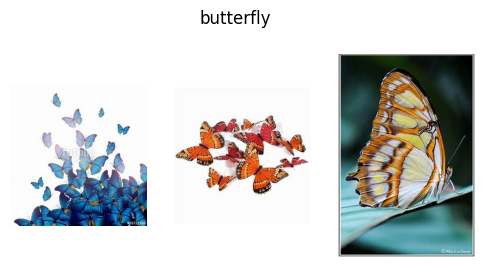

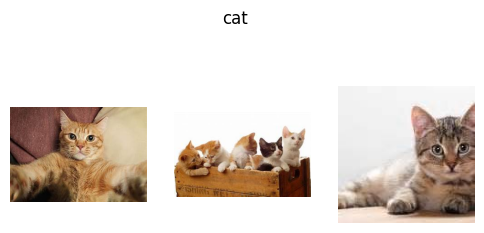

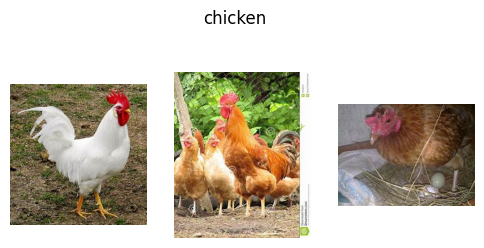

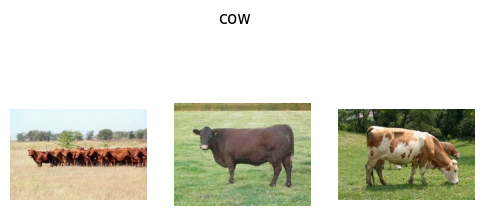

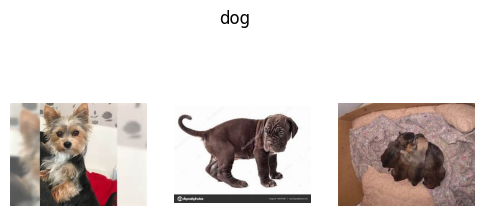

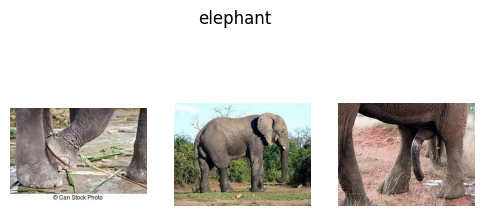

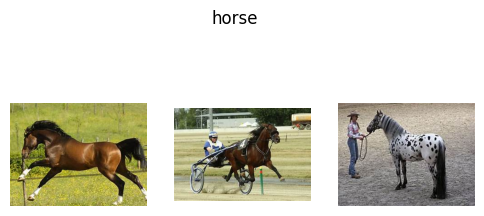

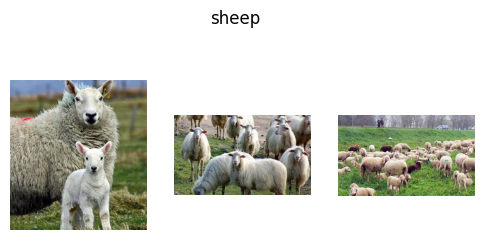

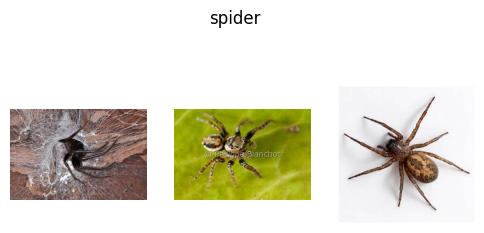

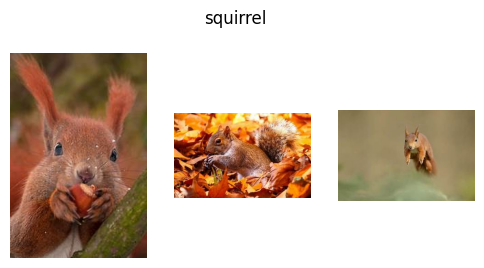

In [24]:
samples_per_class = 3

for class_name, class_index in dataset.class_to_idx.items():
    shown = 0

    plt.figure(figsize=(6, 3))
    plt.suptitle(class_name)

    for image_path, label in dataset.samples:
        if label == class_index:
            image = Image.open(image_path).convert("RGB")

            plt.subplot(1, samples_per_class, shown + 1)
            plt.imshow(image)
            plt.axis("off")

            shown += 1

            if shown == samples_per_class:
                break

    plt.show()

In [25]:
image_sizes= []

for image_path, label in dataset.samples:
    with Image.open(image_path) as image:
        image_sizes.append(image.size)

size_counts= Counter(image_sizes)

print('10 most common sizes:')
for size, count in size_counts.most_common(10):
    print(size, ':', count)

10 most common sizes:
(300, 225) : 4397
(300, 200) : 3281
(300, 300) : 1192
(300, 169) : 1048
(640, 426) : 694
(300, 199) : 586
(225, 300) : 490
(300, 240) : 403
(300, 188) : 393
(200, 300) : 362


In [27]:
file_extensions= []


for image_path, label in dataset.samples:
    extension = image_path.lower().split('.')[-1]
    file_extensions.append(extension)

extension_counts = Counter(file_extensions)

for extension, count in extension_counts.items():
    print(extension, ":", count)

jpeg : 24209
jpg : 1919
png : 51


## SUMMARY SANITYCHECK

1. Loading the dataset is without issues and the desired class labels exists

2. The balance between classes seems **slighty imbalanced** and might affect our model. 
    **After evaluating the model** we will decide if a change in the training data is needed. 

3. No corrupt FilePaths

4. Labels seems to display the correct animal/ picture

5. Most common picture sizes seems be of good size since our model will use size (224 x 224)

6. Training data contains desired filetypes (jpeg/ jpg/ png)